<a href="https://colab.research.google.com/github/iqlore-collab/SUPERVISED-MASHINE-LEARNING-/blob/main/04_advanced_classification_housing_EN_github_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Housing Classification — Grid Search, CV, Ensemble Models and Threshold Tuning

To jest ulepszona wersja notebooka 3.

Zaczynamy od klasycznego workflow:
- baseline,
- decision tree,
- cross-validation,
- GridSearchCV.

Następnie dodajemy mocniejsze elementy praktycznego ML:
- Random Forest,
- Gradient Boosting,
- porównanie modeli,
- ROC-AUC,
- Precision-Recall,
- threshold tuning,
- wybór modelu zależnie od celu biznesowego.

Target:

- `Expensive = 0` — dom nie jest drogi,
- `Expensive = 1` — dom jest drogi.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt


## 2. Load data from Google Drive

In [2]:
file_id = "1nfBXyf1_yJmHnRTp4Xeyz0zGDhCNdpUy"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)
df.head()


,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive
0,8450,65.0,856,3,0,0,2,0,0,0
1,9600,80.0,1262,3,1,0,2,298,0,0
2,11250,68.0,920,3,1,0,2,0,0,0
3,9550,60.0,756,3,1,0,3,0,0,0
4,14260,84.0,1145,4,1,0,3,192,0,0


## 3. Data analysis

In [3]:
print("Rozmiar danych:", df.shape)
print("\nKolumny:")
print(df.columns.tolist())

df.info()


Rozmiar danych: (1460, 10)

Kolumny:
['LotArea', 'LotFrontage', 'TotalBsmtSF', 'BedroomAbvGr', 'Fireplaces', 'PoolArea', 'GarageCars', 'WoodDeckSF', 'ScreenPorch', 'Expensive']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotArea       1460 non-null   int64  
 1   LotFrontage   1201 non-null   float64
 2   TotalBsmtSF   1460 non-null   int64  
 3   BedroomAbvGr  1460 non-null   int64  
 4   Fireplaces    1460 non-null   int64  
 5   PoolArea      1460 non-null   int64  
 6   GarageCars    1460 non-null   int64  
 7   WoodDeckSF    1460 non-null   int64  
 8   ScreenPorch   1460 non-null   int64  
 9   Expensive     1460 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 114.2 KB


In [4]:
df.describe()


,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,70.049958,1057.429452,2.866438,0.613014,2.758904,1.767123,94.244521,15.060959,0.148630
std,9981.264932,24.284752,438.705324,0.815778,0.644666,40.177307,0.747315,125.338794,55.757415,0.355845
min,1300.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7553.500000,59.000000,795.750000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,9478.500000,69.000000,991.500000,3.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000
75%,11601.500000,80.000000,1298.250000,3.000000,1.000000,0.000000,2.000000,168.000000,0.000000,0.000000
max,215245.000000,313.000000,6110.000000,8.000000,3.000000,738.000000,4.000000,857.000000,480.000000,1.000000


In [5]:
df.isna().sum().sort_values(ascending=False)


,0
LotFrontage,259
LotArea,0
TotalBsmtSF,0
BedroomAbvGr,0
Fireplaces,0
PoolArea,0
GarageCars,0
WoodDeckSF,0
ScreenPorch,0
Expensive,0


Missing values appear in the `LotFrontage` feature.

We use `SimpleImputer(strategy="median")` inside the pipeline to avoid data leakage.


## 4. Features and target

In [6]:
target = "Expensive"

features = [
    "LotArea",
    "LotFrontage",
    "TotalBsmtSF",
    "BedroomAbvGr",
    "Fireplaces",
    "PoolArea",
    "GarageCars",
    "WoodDeckSF",
    "ScreenPorch",
]

X = df[features]
y = df[target]

print("X:", X.shape)
print("y:", y.shape)


X: (1460, 9)
y: (1460,)


## 5. Class imbalance

In [7]:
class_summary = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percent": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})

class_summary


,count,percent
Expensive,,
0,1243,85.14
1,217,14.86


Class `1` is much less frequent than class `0`.

Therefore, accuracy alone can be misleading.  
Będziemy oceniać modele przez:

- `accuracy`,
- `balanced_accuracy`,
- `precision_1`,
- `recall_1`,
- `f1_1`,
- `roc_auc`.

For practical usage, it is important to detect expensive houses correctly.


## 6. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (1168, 9)
Test: (292, 9)


## 7. Model evaluation function

In [9]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, threshold=0.5):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_score >= threshold).astype(int)
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        y_score = None
        y_pred_test = model.predict(X_test)
        roc_auc = np.nan

    result = {
        "model": name,
        "threshold": threshold,
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),
        "precision_1": precision_score(y_test, y_pred_test, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_test, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_test, zero_division=0),
        "roc_auc": roc_auc
    }

    return result, y_pred_test, y_score


def confusion_matrix_df(y_true, y_pred):
    return pd.DataFrame(
        confusion_matrix(y_true, y_pred),
        index=["Rzeczywiste 0", "Rzeczywiste 1"],
        columns=["Predykcja 0", "Predykcja 1"]
    )


## 8. Baseline

In [10]:
baseline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_result, y_pred_baseline, _ = evaluate_model(
    "Baseline: most frequent",
    baseline_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([baseline_result]).round(4)


,model,threshold,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.5,0.851,0.8527,0.5,0.0,0.0,0.0,0.5


## 9. Simple tree decyzyjne

In [11]:
simple_tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ))
])

simple_tree_result, y_pred_simple, simple_tree_score = evaluate_model(
    "Simple Decision Tree: max_depth=3",
    simple_tree_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([
    baseline_result,
    simple_tree_result
]).round(4)


,model,threshold,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.5,0.8510,0.8527,0.5000,0.0000,0.0000,0.0000,0.5000
1,Simple Decision Tree: max_depth=3,0.5,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732


## 10. Cross-validation prostego drzewa

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    simple_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Balanced accuracy CV scores:")
print(cv_scores)

print("\nMean:", round(cv_scores.mean(), 4))
print("Std:", round(cv_scores.std(), 4))


Balanced accuracy CV scores:
[0.78994975 0.76891601 0.79590811 0.69331954 0.82099567]

Mean: 0.7738
Std: 0.0435


## 11. Grid Search dla Decision Tree

In [13]:
tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__min_samples_split": [2, 10, 20],
    "model__class_weight": [None, "balanced"]
}

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree params:")
print(tree_grid.best_params_)

print("\nBest CV f1:")
print(round(tree_grid.best_score_, 4))


Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Decision Tree params:
{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Best CV f1:
0.6981


In [14]:
best_tree = tree_grid.best_estimator_

tree_grid_result, y_pred_tree_grid, tree_grid_score = evaluate_model(
    "GridSearch Decision Tree",
    best_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([tree_grid_result]).round(4)


,model,threshold,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,GridSearch Decision Tree,0.5,0.9409,0.9452,0.8717,0.8462,0.7674,0.8049,0.9378


## 12. Random Forest

Random Forest to ensemble wielu drzew decyzyjnych.

Zwykle:
- jest stabilniejszy niż pojedyncze drzewo,
- mniej overfituje,
- daje lepszą generalizację.


In [15]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:")
print(rf_grid.best_params_)

print("\nBest CV f1:")
print(round(rf_grid.best_score_, 4))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Random Forest params:
{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}

Best CV f1:
0.7116


In [16]:
best_rf = rf_grid.best_estimator_

rf_result, y_pred_rf, rf_score = evaluate_model(
    "GridSearch Random Forest",
    best_rf,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([rf_result]).round(4)


,model,threshold,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,GridSearch Random Forest,0.5,0.9392,0.9075,0.8784,0.6429,0.8372,0.7273,0.9397


## 13. Gradient Boosting

Gradient Boosting buduje drzewa sekwencyjnie.

Każde kolejne drzewo próbuje poprawić błędy poprzednich.
To często mocniejszy model niż pojedyncze drzewo.


In [17]:
gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.03, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 5, 10]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting params:")
print(gb_grid.best_params_)

print("\nBest CV f1:")
print(round(gb_grid.best_score_, 4))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Gradient Boosting params:
{'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}

Best CV f1:
0.7146


In [18]:
best_gb = gb_grid.best_estimator_

gb_result, y_pred_gb, gb_score = evaluate_model(
    "GridSearch Gradient Boosting",
    best_gb,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([gb_result]).round(4)


,model,threshold,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,GridSearch Gradient Boosting,0.5,0.9606,0.9315,0.8444,0.7949,0.7209,0.7561,0.9358


## 14. Porównanie wszystkich modeli

In [19]:
comparison_df = pd.DataFrame([
    baseline_result,
    simple_tree_result,
    tree_grid_result,
    rf_result,
    gb_result
])

comparison_df.sort_values(
    by=["f1_1", "balanced_accuracy", "roc_auc"],
    ascending=False
).round(4)


,model,threshold,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
2,GridSearch Decision Tree,0.5,0.9409,0.9452,0.8717,0.8462,0.7674,0.8049,0.9378
4,GridSearch Gradient Boosting,0.5,0.9606,0.9315,0.8444,0.7949,0.7209,0.7561,0.9358
3,GridSearch Random Forest,0.5,0.9392,0.9075,0.8784,0.6429,0.8372,0.7273,0.9397
1,Simple Decision Tree: max_depth=3,0.5,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732
0,Baseline: most frequent,0.5,0.8510,0.8527,0.5000,0.0000,0.0000,0.0000,0.5000


This table shows which model performs best according to different evaluation metrics.

We do not always select the model with the highest accuracy.  
Dla klasy niezbalansowanej ważniejsze mogą być:

- `f1_1`,
- `recall_1`,
- `balanced_accuracy`,
- `roc_auc`.


## 15. ROC curves

<Figure size 800x600 with 0 Axes>

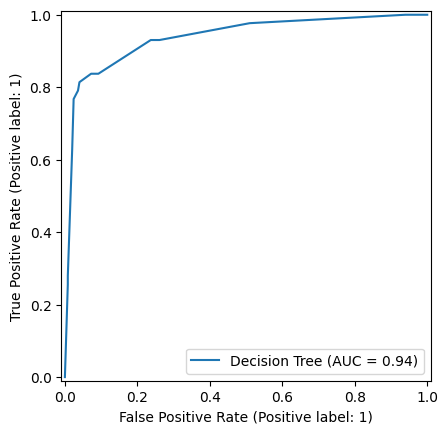

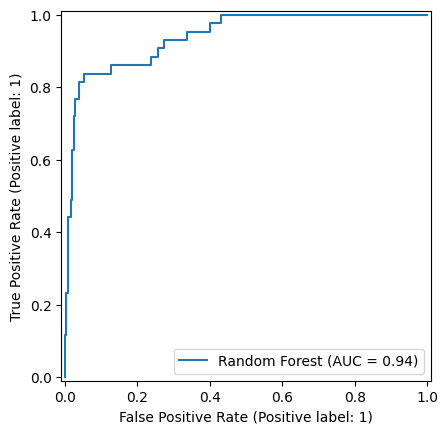

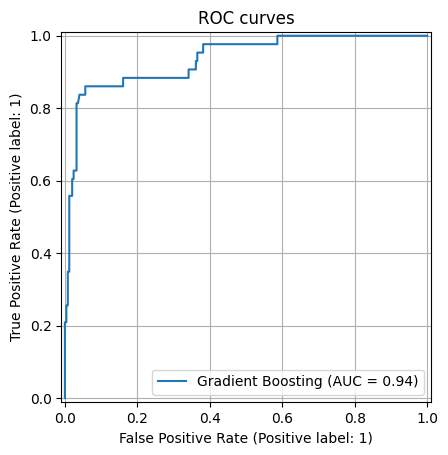

In [20]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(best_tree, X_test, y_test, name="Decision Tree")
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, name="Random Forest")
RocCurveDisplay.from_estimator(best_gb, X_test, y_test, name="Gradient Boosting")

plt.title("ROC curves")
plt.grid(True)
plt.show()


## 16. Precision-Recall curves

<Figure size 800x600 with 0 Axes>

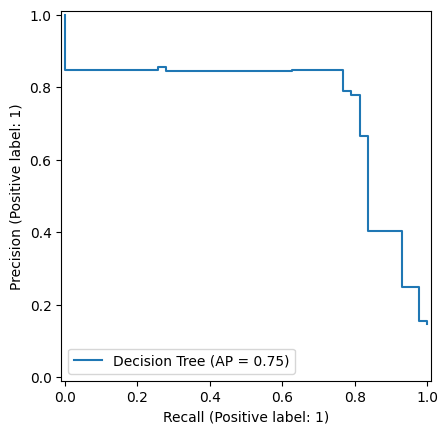

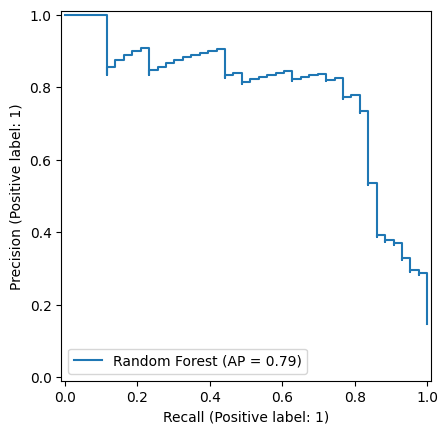

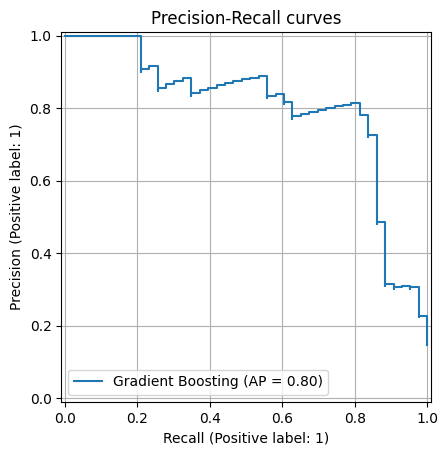

In [21]:
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_estimator(best_tree, X_test, y_test, name="Decision Tree")
PrecisionRecallDisplay.from_estimator(best_rf, X_test, y_test, name="Random Forest")
PrecisionRecallDisplay.from_estimator(best_gb, X_test, y_test, name="Gradient Boosting")

plt.title("Precision-Recall curves")
plt.grid(True)
plt.show()


## 17. Threshold tuning

Domyślnie klasyfikator używa progu `0.5`.

To znaczy:

> jeśli prawdopodobieństwo klasy `1` jest >= 0.5, model przewiduje `Expensive = 1`.

Ale ten próg można zmienić.

Niższy threshold:
- zwiększa recall,
- zmniejsza liczbę przegapionych drogich domów,
- ale zwykle obniża precision.

Wyższy threshold:
- zwiększa precision,
- ale może zmniejszyć recall.


In [22]:
# Wybieramy model bazowy do threshold tuning.
# Możesz zmienić final_candidate na best_rf albo best_tree.

final_candidate = best_gb
final_candidate_name = "Gradient Boosting"

y_score_final = final_candidate.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.05):
    y_pred_threshold = (y_score_final >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_threshold),
        "precision_1": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(by="f1_1", ascending=False).head(10).round(4)


,threshold,accuracy,balanced_accuracy,precision_1,recall_1,f1_1
6,0.40,0.9452,0.8909,0.8140,0.8140,0.8140
5,0.35,0.9452,0.8909,0.8140,0.8140,0.8140
4,0.30,0.9418,0.8985,0.7826,0.8372,0.8090
3,0.25,0.9315,0.9021,0.7255,0.8605,0.7872
7,0.45,0.9384,0.8677,0.8049,0.7674,0.7857
8,0.50,0.9315,0.8444,0.7949,0.7209,0.7561
9,0.55,0.9247,0.8211,0.7838,0.6744,0.7250
2,0.20,0.8973,0.8820,0.6066,0.8605,0.7115
10,0.60,0.9212,0.8095,0.7778,0.6512,0.7089
11,0.65,0.9247,0.7923,0.8387,0.6047,0.7027


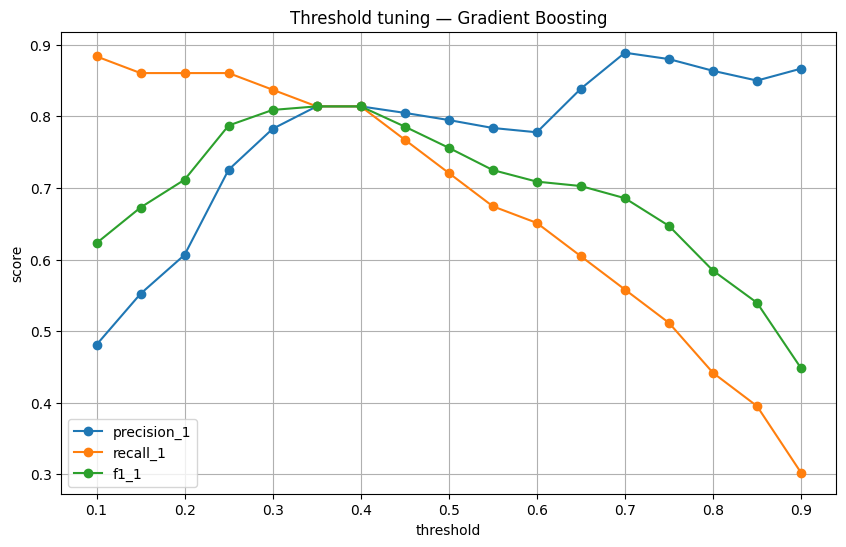

In [23]:
threshold_df.plot(
    x="threshold",
    y=["precision_1", "recall_1", "f1_1"],
    figsize=(10, 6),
    marker="o"
)

plt.title(f"Threshold tuning — {final_candidate_name}")
plt.ylabel("score")
plt.grid(True)
plt.show()


## 18. Wybór finalnego thresholdu

In [24]:
best_threshold_row = threshold_df.sort_values(by="f1_1", ascending=False).iloc[0]
best_threshold = best_threshold_row["threshold"]

print("Best threshold by f1:", round(best_threshold, 2))
best_threshold_row.round(4)


Best threshold by f1: 0.4


,6
threshold,0.4000
accuracy,0.9452
balanced_accuracy,0.8909
precision_1,0.8140
recall_1,0.8140
f1_1,0.8140


In [25]:
y_pred_final = (y_score_final >= best_threshold).astype(int)

final_threshold_result = {
    "model": f"{final_candidate_name} + tuned threshold",
    "threshold": best_threshold,
    "test_accuracy": accuracy_score(y_test, y_pred_final),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_final),
    "precision_1": precision_score(y_test, y_pred_final, zero_division=0),
    "recall_1": recall_score(y_test, y_pred_final, zero_division=0),
    "f1_1": f1_score(y_test, y_pred_final, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_score_final)
}

pd.DataFrame([final_threshold_result]).round(4)


,model,threshold,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Gradient Boosting + tuned threshold,0.4,0.9452,0.8909,0.814,0.814,0.814,0.9358


## 19. Finalna macierz pomyłek

In [26]:
confusion_matrix_df(y_test, y_pred_final)


,Predykcja 0,Predykcja 1
Rzeczywiste 0,241,8
Rzeczywiste 1,8,35


In [27]:
print(classification_report(y_test, y_pred_final, zero_division=0))


              precision    recall  f1-score   support

           0       0.97      0.97      0.97       249
           1       0.81      0.81      0.81        43

    accuracy                           0.95       292
   macro avg       0.89      0.89      0.89       292
weighted avg       0.95      0.95      0.95       292



## 20. Feature importance finalnego modelu

,feature,importance
6,GarageCars,0.500256
2,TotalBsmtSF,0.207425
4,Fireplaces,0.104642
7,WoodDeckSF,0.055510
3,BedroomAbvGr,0.049039
1,LotFrontage,0.040373
0,LotArea,0.039968
8,ScreenPorch,0.002787
5,PoolArea,0.000000


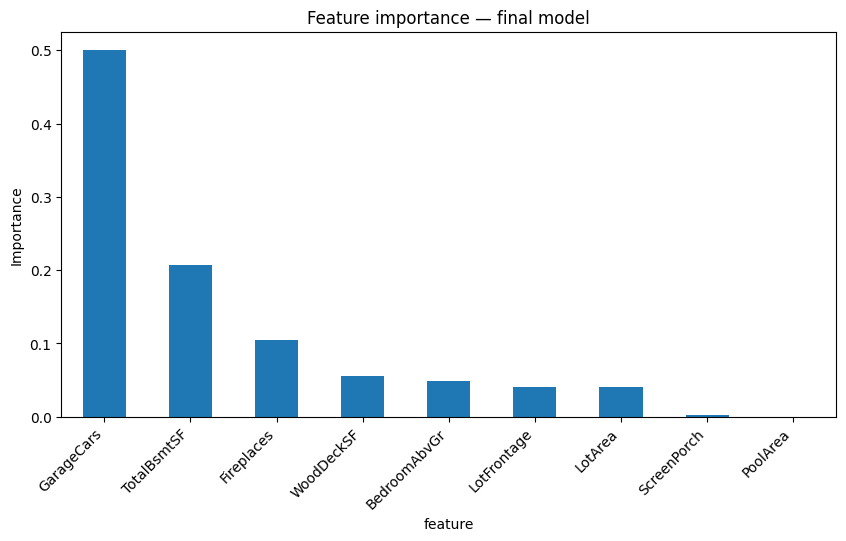

In [28]:
final_model_step = final_candidate.named_steps["model"]

if hasattr(final_model_step, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": final_model_step.feature_importances_
    }).sort_values(by="importance", ascending=False)

    display(importance_df)

    importance_df.plot(
        x="feature",
        y="importance",
        kind="bar",
        figsize=(10, 5),
        legend=False
    )

    plt.title("Feature importance — final model")
    plt.ylabel("Importance")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("Ten model nie ma atrybutu feature_importances_.")


## 21. Final conclusions

In this notebook version, the workflow was significantly improved compared to a single Decision Tree model.

Co dodaliśmy:

1. `GridSearchCV` dla Decision Tree.
2. Random Forest.
3. Gradient Boosting.
4. Porównanie modeli po wielu metrykach.
5. ROC-AUC.
6. Precision-Recall curves.
7. Threshold tuning.
8. Końcowy wybór modelu według praktycznego celu.

Najważniejsze:

- pojedyncze drzewo jest dobre edukacyjnie,
- Random Forest and Gradient Boosting are usually stronger practical models,
- threshold tuning pozwala kontrolować kompromis między precision i recall,
- for imbalanced datasets, accuracy alone is not sufficient.

Ten notebook jest dużo bliżej realnego workflow machine learning.
